# 01 · Attrition Risk Prediction — Random Forest

**Goal** — generate an **attrition risk score** for every employee and flag the high-risk
ones for early HR intervention. The model learns from overtime (`OverTime`), satisfaction
(`JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`), tenure
(`YearsAtCompany`, `YearsSinceLastPromotion`, `TotalWorkingYears`), compensation
(`MonthlyIncome`, `StockOptionLevel`) and role/travel context. This dataset has **no
absence-count feature** — the pipeline is column-agnostic, so it simply trains on the
columns present.

**Algorithm — Random Forest** (`RandomForestClassifier`). Chosen for its robustness to the
mixed, noisy, weakly-correlated HR features here, its insensitivity to feature scaling/outliers,
and the out-of-the-box feature-importance it gives HR. Rationale + citations in
`../MODEL-JUSTIFICATION.md`. Binary classification on `attrition-v2.csv` (IBM HR Analytics
Employee Attrition, 1,470 rows, ~16% leave) — a genuinely-labelled dataset replacing the
near-random synthetic set used previously.

**ERP-servable feature set (deliberate).** We train on **only the columns the Synapse ERP can
actually supply at inference time**, so the model's input contract matches live ERP data. That
means we *exclude*:
- pay-rate / equity columns the ERP doesn't track (`DailyRate`, `MonthlyRate`, `HourlyRate`,
  `PercentSalaryHike`, `StockOptionLevel`),
- `BusinessTravel` (not tracked),
- the survey-only satisfaction scores (`JobSatisfaction`, `EnvironmentSatisfaction`,
  `RelationshipSatisfaction`, `JobInvolvement`, `WorkLifeBalance`) — Synapse runs no engagement survey,
- the **protected attributes** `Gender` and `MaritalStatus` — they must not drive an attrition
  flag (adverse-impact / fairness), consistent with the fairness stance in `MODEL-JUSTIFICATION.md`,
- the three constant book-keeping columns (`EmployeeCount`, `Over18`, `StandardHours`) and the
  `EmployeeNumber` id.

This costs a little accuracy versus the full 30-column model (test ROC-AUC ≈ 0.80 → ≈ 0.74) in
exchange for a model that is **fully servable by the ERP and fairness-defensible** — the right
trade for production. The pipeline is column-agnostic, so the kept set is the single source of truth.

Everything is logged to `logs/attrition*.log`; artifacts (model, metrics, plots, scored
roster) under `artifacts/attrition/`.

In [1]:
# --- environment & logged run -------------------------------------------------------
import sys
from pathlib import Path

# notebooks/ live one level below the model root where synapse_ml.py sits
HERE = Path.cwd()
MODEL_DIR = HERE if (HERE / "synapse_ml.py").exists() else HERE.parent
sys.path.insert(0, str(MODEL_DIR))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)

import synapse_ml as sm
run = sm.start_run("attrition")   # opens logs/attrition_<ts>.log + artifacts/attrition/
log = run.log

INFO    | ==============================================================================


INFO    | RUN START · model=attrition · 2026-06-28T01:07:39


INFO    | python=3.14.4 · platform=Windows-11-10.0.26200-SP0


INFO    | log file=C:\Users\Earl Kian\Documents\Project\synapse\model\logs\attrition_20260628_010739.log


INFO    | artifacts=C:\Users\Earl Kian\Documents\Project\synapse\model\artifacts\attrition


INFO    | libs · numpy=2.5.0, pandas=2.3.3, scipy=1.18.0, sklearn=1.9.0, matplotlib=3.11.0, seaborn=0.13.2


## 1 · Load data

In [2]:
# encoding="utf-8-sig" strips the BOM the source CSV carries on its first header.
df = run.load_csv("attrition-v2.csv", encoding="utf-8-sig")
print(df.shape)
df.head()

INFO    | loading data · C:\Users\Earl Kian\Documents\Project\synapse\model\attrition-v2.csv


INFO    | loaded shape=(1470, 35) · columns=35


(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
import io
_info = io.StringIO()
df.info(buf=_info)
log.info("dataframe info:\n%s", _info.getvalue())
df.describe(include="all").T

INFO    | dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


## 2 · Target & exploratory analysis

INFO    | target=Attrition · positive rate=0.161 (237 of 1470)


INFO    | saved figure · 01_class_balance.png


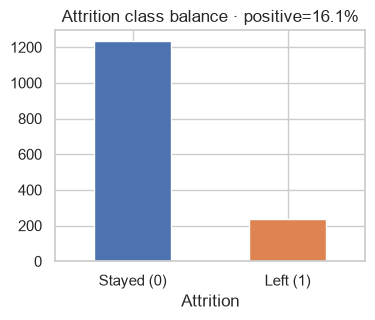

In [4]:
TARGET = "Attrition"

# ---- ERP-servable feature set -------------------------------------------------------
# The model is trained on ONLY these columns so its input contract == what the Synapse
# ERP can produce at inference time (see the markdown above for what is excluded and why).
# This list is the single source of truth for the model's features.
FEATURES = [
    "Age", "Department", "JobRole", "JobLevel", "MonthlyIncome", "OverTime",
    "PerformanceRating", "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager", "TotalWorkingYears",
    "TrainingTimesLastYear", "Education", "EducationField",
    "NumCompaniesWorked", "DistanceFromHome",
]

y = (df[TARGET].astype(str).str.strip().str.lower() == "yes").astype(int)
rate = y.mean()
log.info("target=%s · positive rate=%.3f (%d of %d)", TARGET, rate, y.sum(), len(y))

fig, ax = plt.subplots(figsize=(4, 3))
y.value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_xticklabels(["Stayed (0)", "Left (1)"], rotation=0)
ax.set_title(f"Attrition class balance · positive={rate:.1%}")
run.save_fig(fig, "01_class_balance"); plt.show()

INFO    | attrition rate by OverTime:
OverTime
Yes    0.305288
No     0.104364


INFO    | attrition rate by JobSatisfaction:
JobSatisfaction
1    0.228374
3    0.165158
2    0.164286
4    0.113290


INFO    | attrition rate by Department:
Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398


INFO    | saved figure · 02_attrition_by_driver.png


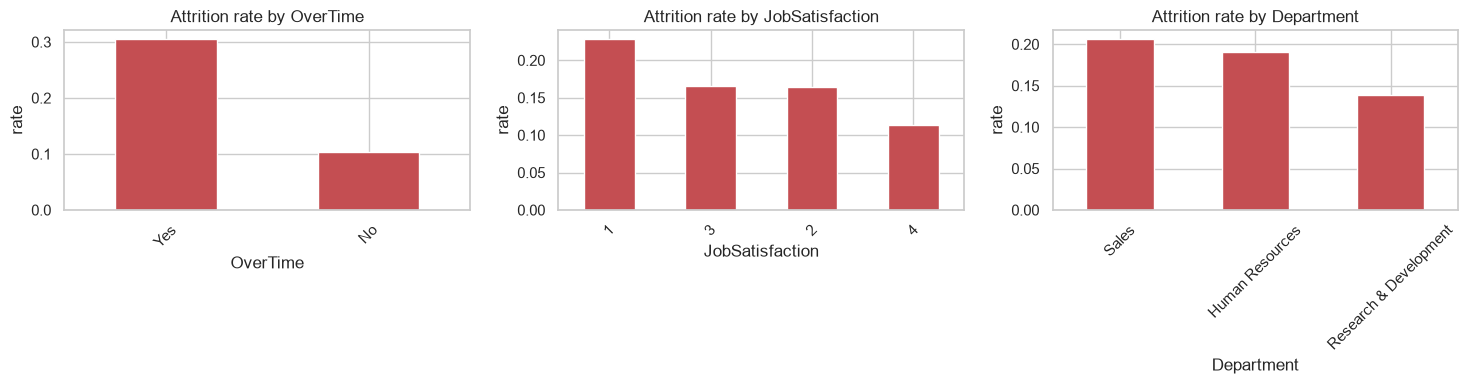

In [5]:
# Attrition rate across the drivers the model is meant to read.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["OverTime", "JobSatisfaction", "Department"]):
    rates = df.assign(_y=y).groupby(col)["_y"].mean().sort_values(ascending=False)
    log.info("attrition rate by %s:\n%s", col, rates.to_string())
    rates.plot(kind="bar", ax=ax, color="#c44e52")
    ax.set_title(f"Attrition rate by {col}"); ax.set_ylabel("rate")
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout(); run.save_fig(fig, "02_attrition_by_driver"); plt.show()

INFO    | numeric correlation with attrition:
TotalWorkingYears         -0.171063
JobLevel                  -0.169105
YearsInCurrentRole        -0.160545
MonthlyIncome             -0.159840
Age                       -0.159205
YearsWithCurrManager      -0.156199
YearsAtCompany            -0.134392
TrainingTimesLastYear     -0.059478
YearsSinceLastPromotion   -0.033019
Education                 -0.031373
PerformanceRating          0.002889
NumCompaniesWorked         0.043494
DistanceFromHome           0.077924


INFO    | saved figure · 03_numeric_correlation.png


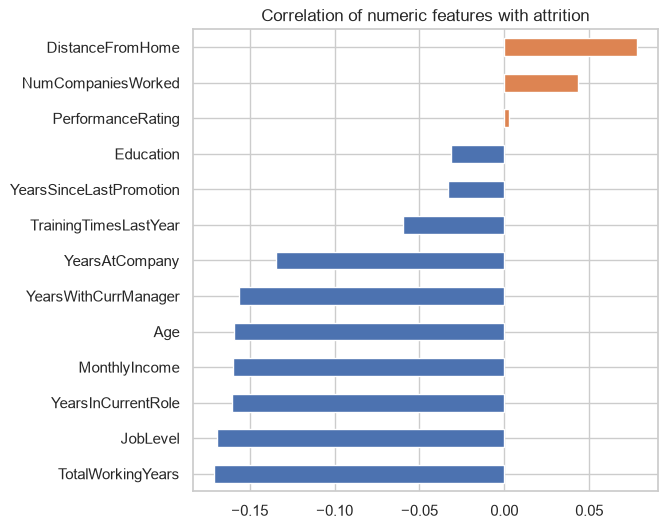

In [6]:
num_df = df[FEATURES].select_dtypes("number").assign(_attr=y)
corr = num_df.corr()["_attr"].drop("_attr").sort_values()
log.info("numeric correlation with attrition:\n%s", corr.to_string())

fig, ax = plt.subplots(figsize=(6, 6))
corr.plot(kind="barh", ax=ax, color=np.where(corr > 0, "#dd8452", "#4c72b0"))
ax.set_title("Correlation of numeric features with attrition")
run.save_fig(fig, "03_numeric_correlation"); plt.show()

## 3 · Preprocessing & stratified split

A `ColumnTransformer` median-imputes + scales numerics and mode-imputes + one-hot-encodes
categoricals. (Random Forests don't need scaling, but a single shared recipe keeps the three
notebooks consistent and harmless here.) Stratified split preserves the ~16% leave rate.

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df[FEATURES]
numeric_cols, categorical_cols = sm.split_feature_types(df[FEATURES + [TARGET]], target=TARGET)
log.info("numeric=%d %s", len(numeric_cols), numeric_cols)
log.info("categorical=%d %s", len(categorical_cols), categorical_cols)

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     categorical_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
log.info("split · train=%s test=%s", X_train.shape, X_test.shape)

INFO    | numeric=13 ['Age', 'JobLevel', 'MonthlyIncome', 'PerformanceRating', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TotalWorkingYears', 'TrainingTimesLastYear', 'Education', 'NumCompaniesWorked', 'DistanceFromHome']


INFO    | categorical=4 ['Department', 'JobRole', 'OverTime', 'EducationField']


INFO    | split · train=(1176, 17) test=(294, 17)


## 4 · Random Forest model

`class_weight="balanced_subsample"` re-weights each bootstrap to counter the imbalance.
Quality is read from 5-fold ROC-AUC before the final fit on all training data.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=2,
        max_features="sqrt", class_weight="balanced_subsample",
        n_jobs=-1, random_state=42)),
])

cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
log.info("CV ROC-AUC = %.4f (+/- %.4f)", cv_auc.mean(), cv_auc.std())
model.fit(X_train, y_train)
log.info("fitted RandomForest on %d rows", len(X_train))

INFO    | CV ROC-AUC = 0.7853 (+/- 0.0206)


INFO    | fitted RandomForest on 1176 rows


## 5 · Evaluation

In [9]:
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
                             PrecisionRecallDisplay)

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
roc = roc_auc_score(y_test, proba)
pr_auc = average_precision_score(y_test, proba)
report = classification_report(y_test, pred, target_names=["Stayed", "Left"], digits=3)
log.info("test ROC-AUC=%.4f · PR-AUC=%.4f", roc, pr_auc)
log.info("classification report @0.5:\n%s", report)
print(report)

INFO    | test ROC-AUC=0.7369 · PR-AUC=0.3731


INFO    | classification report @0.5:
              precision    recall  f1-score   support

      Stayed      0.859     0.939     0.897       247
        Left      0.375     0.191     0.254        47

    accuracy                          0.820       294
   macro avg      0.617     0.565     0.576       294
weighted avg      0.782     0.820     0.795       294



              precision    recall  f1-score   support

      Stayed      0.859     0.939     0.897       247
        Left      0.375     0.191     0.254        47

    accuracy                          0.820       294
   macro avg      0.617     0.565     0.576       294
weighted avg      0.782     0.820     0.795       294



INFO    | saved figure · 04_evaluation_curves.png


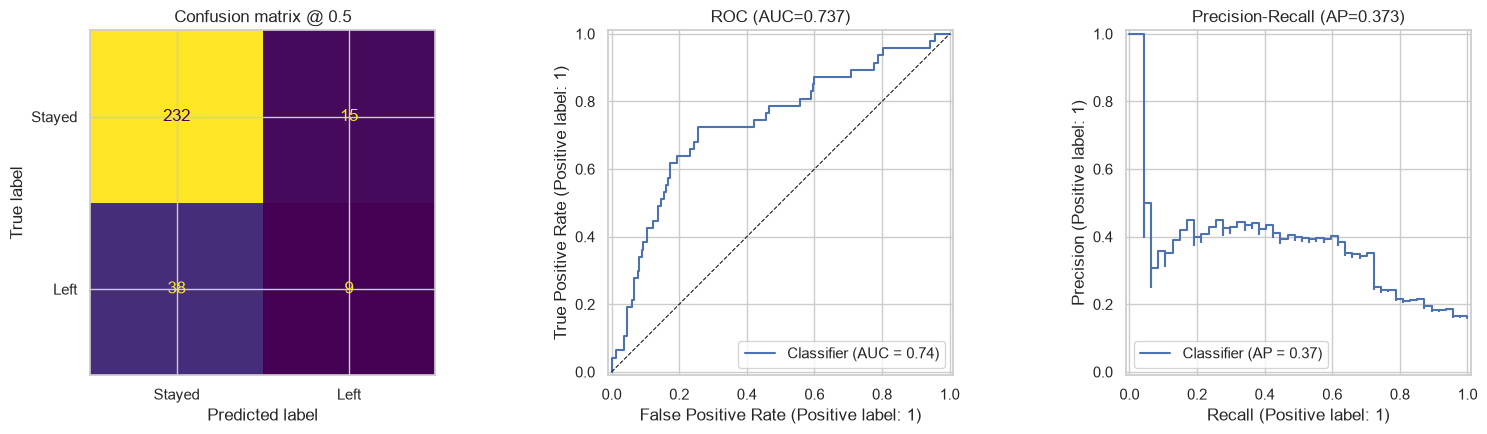

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["Stayed", "Left"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix @ 0.5")
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].set_title(f"ROC (AUC={roc:.3f})"); axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[2])
axes[2].set_title(f"Precision-Recall (AP={pr_auc:.3f})")
fig.tight_layout(); run.save_fig(fig, "04_evaluation_curves"); plt.show()

INFO    | top RF feature importances:
MonthlyIncome                    0.116901
Age                              0.100821
TotalWorkingYears                0.081225
DistanceFromHome                 0.073572
YearsAtCompany                   0.069186
NumCompaniesWorked               0.065844
YearsWithCurrManager             0.062131
YearsInCurrentRole               0.049042
OverTime_Yes                     0.041024
YearsSinceLastPromotion          0.040103
OverTime_No                      0.040081
JobLevel                         0.035902
TrainingTimesLastYear            0.033361
Education                        0.033337
JobRole_Laboratory Technician    0.015045


INFO    | saved figure · 05_feature_importance.png


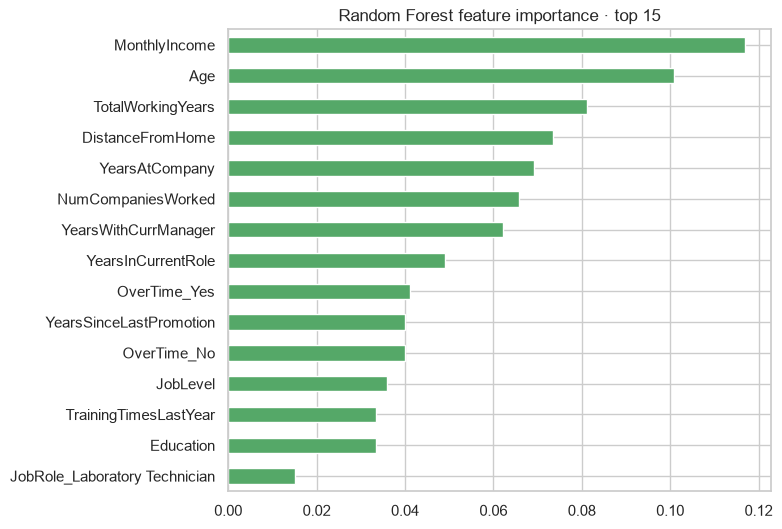

In [11]:
# Random Forest impurity importances (native) — what drives the risk score.
ohe = model.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
feat_names = numeric_cols + list(ohe.get_feature_names_out(categorical_cols))
importances = pd.Series(model.named_steps["clf"].feature_importances_, index=feat_names)
top = importances.sort_values().tail(15)
log.info("top RF feature importances:\n%s", top.sort_values(ascending=False).to_string())

fig, ax = plt.subplots(figsize=(7, 6))
top.plot(kind="barh", ax=ax, color="#55a868")
ax.set_title("Random Forest feature importance · top 15")
run.save_fig(fig, "05_feature_importance"); plt.show()

## 6 · Decision-threshold tuning

Missing a leaver (false negative) is the costly error, so we pick the threshold maximising F1
on the "Left" class instead of defaulting to 0.5.

INFO    | tuned threshold=0.289 · F1=0.487 · recall=0.617 · precision=0.403


              precision    recall  f1-score   support

      Stayed      0.919     0.826     0.870       247
        Left      0.403     0.617     0.487        47

    accuracy                          0.793       294
   macro avg      0.661     0.721     0.679       294
weighted avg      0.836     0.793     0.809       294

INFO    | saved figure · 06_threshold_sweep.png


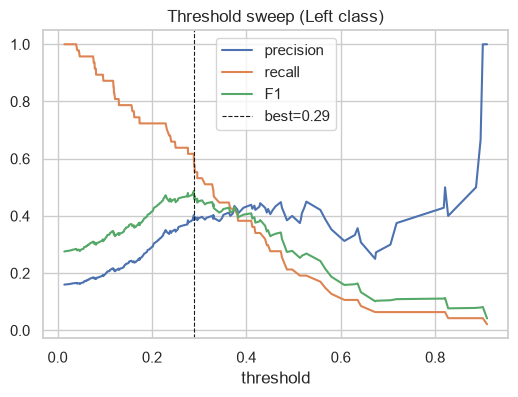

In [12]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, proba)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1s[:-1]))
best_thr = float(thr[best_idx])
log.info("tuned threshold=%.3f · F1=%.3f · recall=%.3f · precision=%.3f",
         best_thr, f1s[best_idx], rec[best_idx], prec[best_idx])
print(classification_report(y_test, (proba >= best_thr).astype(int),
                            target_names=["Stayed", "Left"], digits=3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thr, prec[:-1], label="precision"); ax.plot(thr, rec[:-1], label="recall")
ax.plot(thr, f1s[:-1], label="F1")
ax.axvline(best_thr, color="k", ls="--", lw=0.8, label=f"best={best_thr:.2f}")
ax.set_xlabel("threshold"); ax.set_title("Threshold sweep (Left class)"); ax.legend()
run.save_fig(fig, "06_threshold_sweep"); plt.show()

## 7 · Risk scoring & high-risk flags

The headline deliverable: turn probabilities into a 0–100 **attrition risk score** and bucket
employees into Low / Medium / High tiers for HR. The scored test roster is checkpointed to
`artifacts/attrition/`.

In [13]:
scored = X_test.copy()
scored["risk_score"] = (proba * 100).round(1)
scored["actual_attrition"] = y_test.values
scored["risk_tier"] = pd.cut(proba, bins=[-0.01, 0.33, 0.66, 1.01],
                             labels=["Low", "Medium", "High"])
tier_counts = scored["risk_tier"].value_counts().sort_index()
log.info("risk tier distribution:\n%s", tier_counts.to_string())

high_risk = scored.sort_values("risk_score", ascending=False).head(10)
log.info("top-10 highest-risk employees:\n%s",
         high_risk[["risk_score", "risk_tier", "actual_attrition"]].to_string())
run.checkpoint_df(scored.reset_index(names="row_id"), "scored_test_roster")
high_risk[["risk_score", "risk_tier", "actual_attrition"]]

INFO    | risk tier distribution:
risk_tier
Low       235
Medium     47
High       12


INFO    | top-10 highest-risk employees:
      risk_score risk_tier  actual_attrition
911         91.0      High                 1
688         90.1      High                 1
17          89.6      High                 0
1061        88.7      High                 0
1402        82.8      High                 0
711         82.1      High                 1
301         81.8      High                 0
41          71.8      High                 0
476         71.1      High                 0
109         70.5      High                 0


WARNING | parquet unavailable (Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.); wrote CSV instead


INFO    | checkpoint dataframe · scored_test_roster.csv · shape=(294, 21)


,risk_score,risk_tier,actual_attrition
911,91.0,High,1
688,90.1,High,1
17,89.6,High,0
1061,88.7,High,0
1402,82.8,High,0
711,82.1,High,1
301,81.8,High,0
41,71.8,High,0
476,71.1,High,0
109,70.5,High,0


## 8 · Persist model, metrics & serving contract

Besides the fitted pipeline and headline metrics we write a **`feature_contract.json`** — the
exact ordered feature columns, the categorical levels seen in training, the tuned decision
threshold and the risk-tier cut-points. The Laravel serving layer (`MlClient` + the attrition
feature mapper) reads this so the ERP feeds the model exactly what it was trained on.

In [14]:
run.save_model(model, "attrition_model")
run.save_metrics({
    "algorithm": "RandomForestClassifier",
    "cv_roc_auc": float(cv_auc.mean()),
    "test_roc_auc": roc,
    "test_pr_auc": pr_auc,
    "tuned_threshold": best_thr,
    "tuned_recall_left": float(rec[best_idx]),
    "tuned_precision_left": float(prec[best_idx]),
    "positive_rate": float(rate),
    "high_risk_count": int((scored["risk_tier"] == "High").sum()),
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "n_features": len(FEATURES),
})

# Serving contract — the source of truth for what the ERP must send at inference time.
contract = {
    "target": TARGET,
    "feature_columns": list(FEATURES),
    "numeric_columns": list(numeric_cols),
    "categorical_columns": list(categorical_cols),
    "categorical_levels": {c: sorted(map(str, df[c].dropna().unique())) for c in categorical_cols},
    "tuned_threshold": best_thr,
    "risk_tier_bins": {"low_max": 0.33, "medium_max": 0.66},
    "positive_rate": float(rate),
}
run.save_metrics(contract, name="feature_contract")
log.info("serving contract written · %d features", len(FEATURES))
run.finish(summary=f"RandomForest (ERP-servable {len(FEATURES)} feats): test ROC-AUC={roc:.3f}, PR-AUC={pr_auc:.3f}, tuned thr={best_thr:.2f}")

INFO    | saved model · attrition_model.joblib (11129.6 KB)


INFO    | saved metrics · metrics.json


INFO    |   algorithm                    = RandomForestClassifier


INFO    |   cv_roc_auc                   = 0.7853


INFO    |   test_roc_auc                 = 0.7369


...

INFO    |   positive_rate                = 0.1612


INFO    | serving contract written · 17 features


INFO    | summary · RandomForest (ERP-servable 17 feats): test ROC-AUC=0.737, PR-AUC=0.373, tuned thr=0.29


INFO    | RUN END · model=attrition · elapsed=9.3s


INFO    | ==============================================================================
